In [2]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [3]:
from phisat2.data_loaders import build_datamodule
from phisat2.tasks import resolve_task_spec
from phisat2.utils.seed import seed_everything
from phisat2.utils.visualization import visualize_triplet_batch

In [4]:
ROOT_DIR = "/lustre/home/u10010021/phisat2/data/triplets"
BATCH_SIZE = 4              
SEED = 42

In [5]:
seed_everything(SEED)

spec = resolve_task_spec("pretrain_reconstruction", "triplets")

datamodule = build_datamodule(
    "triplets",
    root_dir=ROOT_DIR,
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=SEED,
    crop_size=256,
    fast_dev_run=False
)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()

In [9]:
for i, batch in enumerate(test_loader):
    if i >= 10:
        break

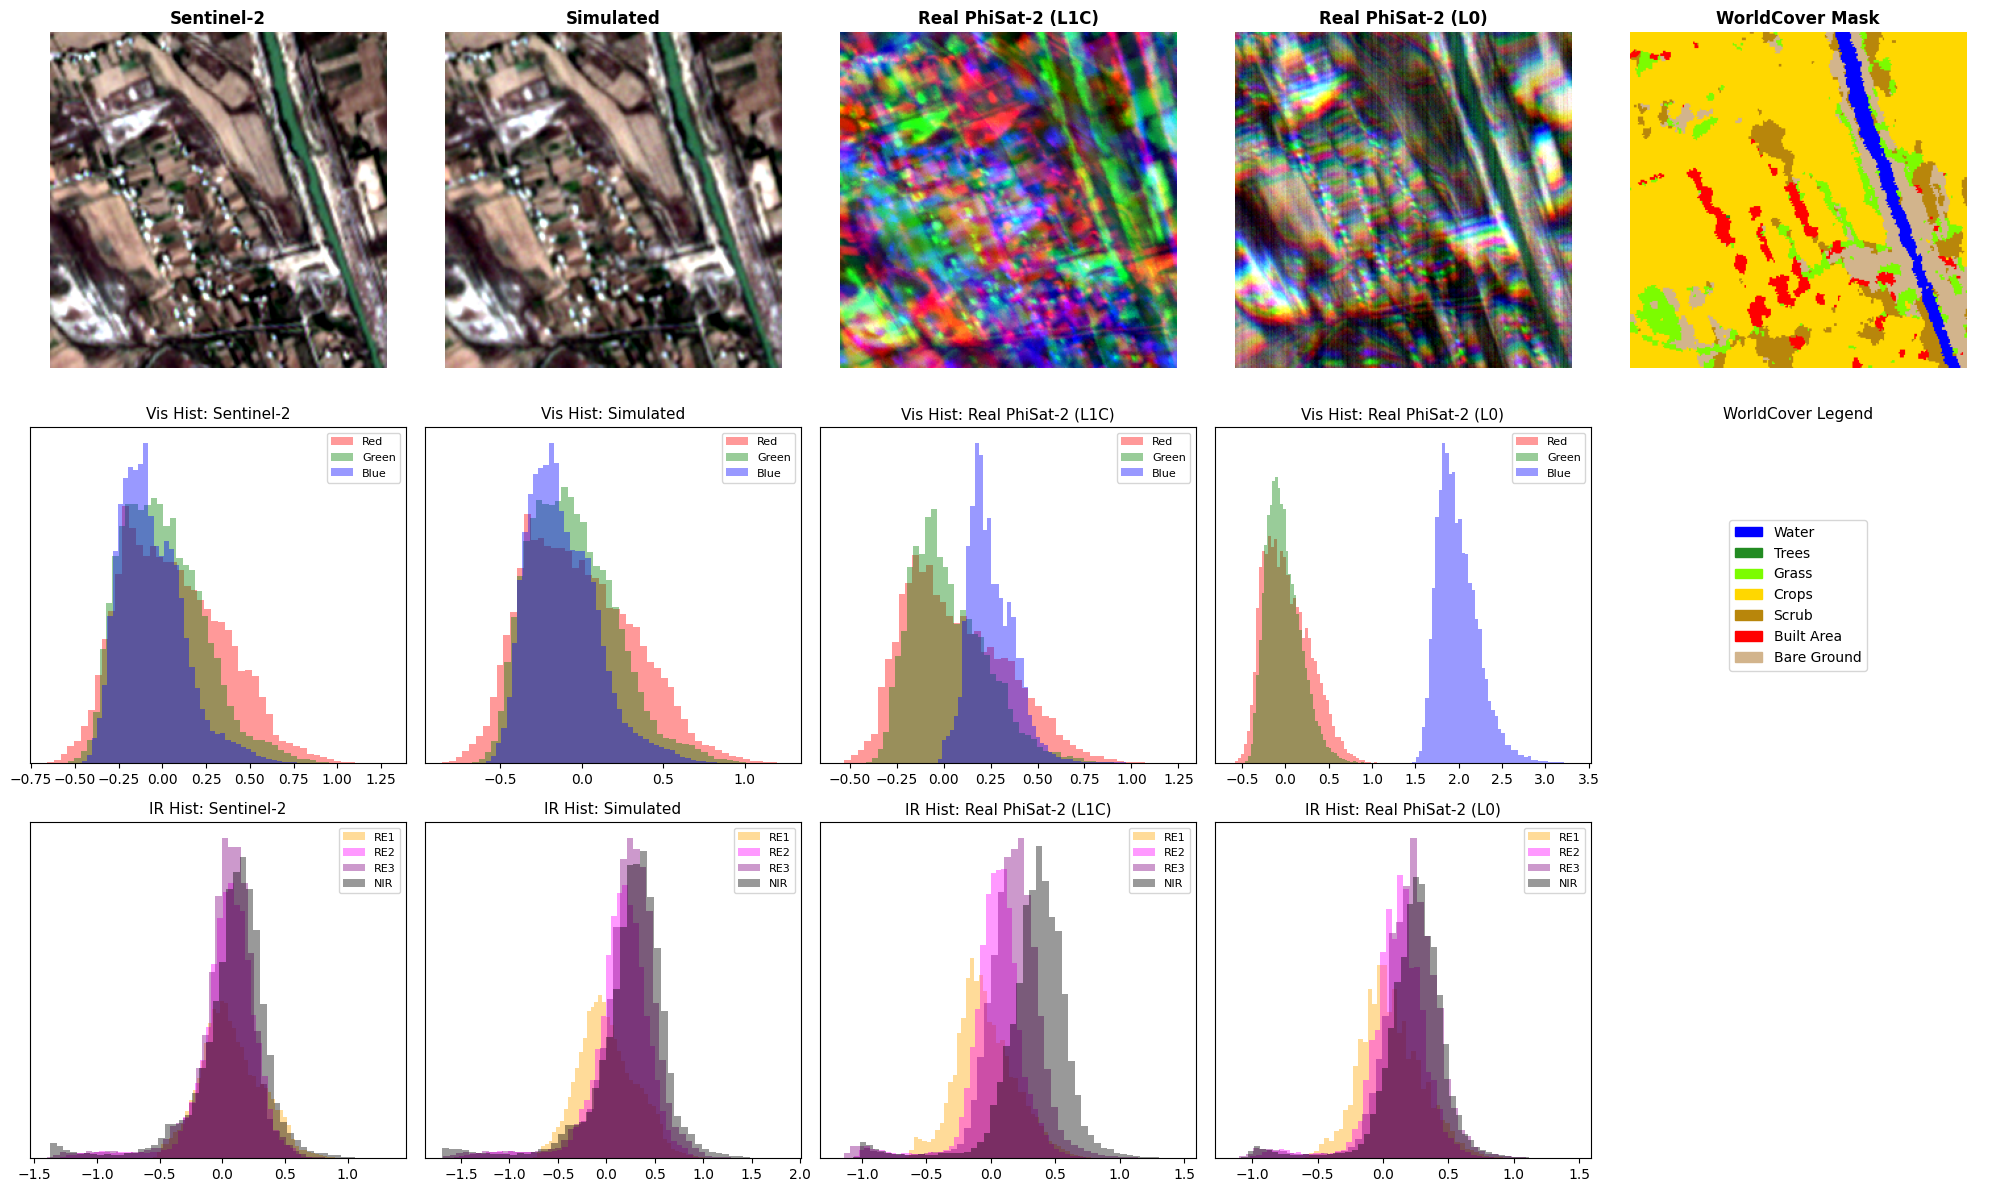

In [10]:
visualize_triplet_batch(batch, idx=0, show_cloud=False, show_worldcover=True)#,zoom_box=(100, 100, 150, 150))